# Day 7: Bayesian Deep Learning

Regime Lab (Zetheta Algorithms internship, Task 1A), Section D2, Day 7.

Builds the three Bayesian classifiers from Section A4 (MC Dropout, a
variational BNN, a deep ensemble), compares them on time-series
cross-validation, decomposes uncertainty into epistemic and aleatoric
parts and produces SHAP attributions for selected dates.

Three things to know before reading the numbers:

1. **The labels are not ground truth.** Section A4.6 trains on regime
   labels decoded from an HMM. Here that is Day 4's frequentist HMM, which
   Day 4 already showed to be weakly identified: **88.6% of days get the
   same label** ("Risk-On"). The decode also runs over the whole series,
   so a label at day *t* uses future returns, and the HMM saw the test
   periods. Both are features of the spec's design, not fixed here.
2. **So accuracy is close to meaningless.** Always predicting the majority
   class scores about 89%. Every table below carries the majority/prior
   baseline, balanced accuracy and negative log-likelihood beside
   accuracy.
3. **TensorFlow lives in `.venv-bayesian`** (kernel `bayesian-env`), the
   same isolated environment as PyMC. Training ran in
   `scripts/run_day7_*.py`; this notebook loads their saved outputs.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

from src.models.bdl.evaluation import classification_metrics
from src.utils.plot_style import new_figure, PALETTE

pd.set_option('display.precision', 3); pd.set_option('display.width', 200)
REGIMES = ['Risk-On', 'Late-Cycle', 'Transitional', 'Post-Shock', 'Risk-Off']

## 1. The labels and their balance

In [2]:
labels = pd.read_csv('../artifacts_data/day7_labels.csv', index_col=0, parse_dates=True)['regime']
feats = pd.read_csv('../artifacts_data/day7_features.csv', index_col=0, parse_dates=True)
print(f"{len(labels)} days, {feats.shape[1]} features, {labels.index.min().date()} to {labels.index.max().date()}")
counts = labels.value_counts().reindex(REGIMES)
pd.DataFrame({'days': counts, 'share': counts / counts.sum()})

3508 days, 31 features, 2012-01-18 to 2025-06-27


,days,share
regime,,
Risk-On,3107,0.886
Late-Cycle,37,0.011
Transitional,83,0.024
Post-Shock,143,0.041
Risk-Off,138,0.039


Late-Cycle has 37 days in the whole sample. Every cross-validation
fold's test window therefore holds only a handful of days for the rare
classes, and (shown next) the rare classes are *clustered in time*, so
some early folds contain none at all.

## 2. Time-series cross-validation (Section A4.6)

Five expanding-window folds (`TimeSeriesSplit`), scaler fit on each
fold's training slice only. Reduced from the spec's M=8 / 50 epochs to
M=5 / 30 epochs so five folds fit the per-call budget (the
early-stopped ensemble allows up to 50 epochs). An extra
class-weighted MC Dropout row is included because the imbalance is the
dominant fact about this dataset.

In [3]:
folds = [json.load(open(f'../artifacts_data/day7_cv_fold{f}.json')) for f in range(5)]
info = pd.DataFrame([{'fold': d['fold'], 'n_train': d['n_train'], 'n_test': d['n_test'],
                      **{f'train_{r}': c for r, c in zip(REGIMES, d['train_class_counts'])},
                      **{f'test_{r}': c for r, c in zip(REGIMES, d['test_class_counts'])}} for d in folds]).set_index('fold')
info[['n_train','n_test'] + [f'test_{r}' for r in REGIMES]]

,n_train,n_test,test_Risk-On,test_Late-Cycle,test_Transitional,test_Post-Shock,test_Risk-Off
fold,,,,,,,
0,588,584,561,6,17,0,0
1,1172,584,575,3,6,0,0
2,1756,584,488,9,18,35,34
3,2340,584,465,8,18,47,46
4,2924,584,518,7,13,24,22


Folds 0 and 1 have **no Post-Shock or Risk-Off days in the test window
at all**: all of those labels sit later in the sample. On those folds
"balanced accuracy" is averaged over only the three classes present, and
a majority-class predictor scores 1/3.

In [4]:
summary = pd.read_csv('../artifacts_data/day7_cv_summary.csv')
order = ['majority/prior baseline', 'mc_dropout', 'mc_dropout_weighted', 'variational_bnn',
         'deep_ensemble', 'deep_ensemble_dropout_members', 'deep_ensemble_early_stop']
tab = summary.groupby('model')[['acc', 'bal_acc', 'macro_f1', 'nll']].mean().loc[order]
tab

,acc,bal_acc,macro_f1,nll
model,,,,
majority/prior baseline,0.893,0.253,NaN,0.502
mc_dropout,0.898,0.288,0.289,0.421
mc_dropout_weighted,0.813,0.366,0.288,0.543
variational_bnn,0.896,0.299,0.273,0.352
deep_ensemble,0.893,0.299,0.299,0.644
deep_ensemble_dropout_members,0.897,0.285,0.263,0.455
deep_ensemble_early_stop,0.892,0.272,0.264,0.431


In [5]:
piv = summary.pivot(index='fold', columns='model', values='nll')
prior = piv['majority/prior baseline']
rel = piv.sub(prior, axis=0).drop(columns='majority/prior baseline')[order[1:]]
print("NLL minus class-prior NLL, per fold (negative = beats a model that only knows class frequencies):")
print(rel.round(3).to_string())
print()
print("Folds where the model beats the prior on NLL:")
print((rel < 0).sum().to_string())

NLL minus class-prior NLL, per fold (negative = beats a model that only knows class frequencies):
model  mc_dropout  mc_dropout_weighted  variational_bnn  deep_ensemble  deep_ensemble_dropout_members  deep_ensemble_early_stop
fold                                                                                                                           
0          -0.095                0.035           -0.085         -0.094                         -0.070                    -0.095
1          -0.091                0.117           -0.084         -0.078                         -0.089                    -0.066
2          -0.113                0.174           -0.224          0.271                         -0.091                     0.050
3           0.013               -0.116           -0.168          0.533                          0.079                    -0.129
4          -0.122               -0.006           -0.192          0.075                         -0.064                    -0.118

Folds

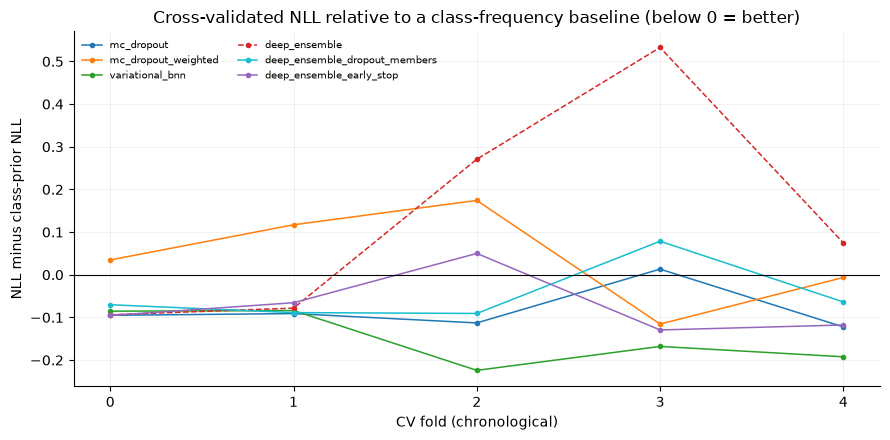

In [6]:
fig, ax = new_figure()
style = {'mc_dropout': PALETTE[0], 'mc_dropout_weighted': PALETTE[4], 'variational_bnn': PALETTE[2],
         'deep_ensemble': PALETTE[1], 'deep_ensemble_dropout_members': PALETTE[5], 'deep_ensemble_early_stop': PALETTE[3]}
for m in rel.columns:
    ax.plot(rel.index, rel[m], marker='o', markersize=3, label=m, color=style[m],
            linestyle='--' if m == 'deep_ensemble' else '-')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(5)); ax.set_xlabel('CV fold (chronological)')
ax.set_ylabel('NLL minus class-prior NLL')
ax.set_title('Cross-validated NLL relative to a class-frequency baseline (below 0 = better)')
ax.legend(fontsize=7, ncol=2)
fig.tight_layout(); fig.savefig('../docs/artifacts/day7_cv_nll_vs_prior.png', dpi=110)

In [7]:
acc = summary.pivot(index='fold', columns='model', values='acc')
bal = summary.pivot(index='fold', columns='model', values='bal_acc')
base_acc, base_bal = acc['majority/prior baseline'], bal['majority/prior baseline']
rows = []
for m in ['mc_dropout', 'variational_bnn', 'deep_ensemble_early_stop', 'mc_dropout_weighted']:
    rows.append({'model': m,
                 'accuracy minus baseline (mean)': (acc[m] - base_acc).mean(),
                 'accuracy minus baseline (range)': f"[{(acc[m]-base_acc).min():+.3f}, {(acc[m]-base_acc).max():+.3f}]",
                 'bal_acc minus baseline (mean)': (bal[m] - base_bal).mean(),
                 'folds with bal_acc above baseline': int(((bal[m] - base_bal) > 1e-9).sum())})
pd.DataFrame(rows).set_index('model')

,accuracy minus baseline (mean),accuracy minus baseline (range),bal_acc minus baseline (mean),folds with bal_acc above baseline
model,,,,
mc_dropout,0.005,"[+0.000, +0.015]",0.034,3
variational_bnn,0.003,"[-0.010, +0.017]",0.046,3
deep_ensemble_early_stop,-0.001,"[-0.003, +0.000]",0.018,2
mc_dropout_weighted,-0.080,"[-0.164, -0.048]",0.113,5


**What this shows.** Read against the baselines rather than in
isolation:

- **Accuracy.** The three standard models sit within about ±0.02 of the
  majority-class baseline in every fold. They are not detecting regimes
  better than "always Risk-On" by that measure.
- **NLL.** The variational BNN beats the class-prior baseline in every
  fold, the most consistent result here. MC Dropout and the
  early-stopped ensemble beat it in most folds. So the features carry
  *some* information about the labels beyond their base rate, which is
  unsurprising given the labels were decoded from returns and the
  features include returns and volatility.
- **Class weights** put balanced accuracy above the majority baseline
  in all five folds, and above the *unweighted* MC Dropout in three of
  five, but they cost 5-16 accuracy points in every fold and leave mean
  NLL worse than the prior (better in only 2 folds). They trade
  calibration for minority-class recall; not a free win. (The
  weighted-vs-unweighted balanced-accuracy comparison flipped in two
  folds between two of my training runs, TensorFlow's CPU kernels not
  being bit-deterministic, so treat the "three of five" as soft.)
- **Ranking the three architectures is not supported.** Their mean
  differences are small next to fold-to-fold spread, and each fold's
  rare-class scores rest on 3-47 days.

### The spec's ensemble recipe overfits here

The plain deterministic ensemble (30 epochs, no early stopping) is
*worse than the class-prior baseline in 3 of 5 folds*. Section A4.4 calls
deep ensembles among the most reliable Bayesian approaches, so this needed
explaining rather than reporting. Training-length diagnostic on fold 3:

In [8]:
diag = json.load(open('../artifacts_data/day7_overfit_diagnostic.json'))
d = pd.DataFrame(diag['by_epochs']).T
d.index.name = 'epochs'
print(f"fold {diag['fold']} class-prior NLL: {diag['prior_frequency_nll']:.3f}")
d[['nll', 'accuracy', 'balanced_accuracy', 'mean_confidence_on_wrong_days']]

fold 3 class-prior NLL: 0.815


,nll,accuracy,balanced_accuracy,mean_confidence_on_wrong_days
epochs,,,,
3,0.598,0.818,0.256,0.665
10,0.773,0.818,0.255,0.722
30,1.453,0.807,0.247,0.826


NLL rises with training length while accuracy is flat, and confidence
on wrong days rises with it: the ensemble becomes *more sure of its
mistakes*, the signature of overconfidence under distribution shift. That
is a property of an unregularised training recipe on this data, not of
ensembles as such. The fix used is early stopping on a chronological
validation slice taken from the **training** window only (the last 20%
of it), which never looks at the test fold. The NLL for the same
architecture fell accordingly (table above, `deep_ensemble_early_stop`).
The 30-epoch NLL varies by about 0.1 between runs (1.33, 1.35 and
1.45 across three runs I made; TensorFlow's CPU kernels are not
bit-deterministic); the direction does not.

One further design point, about what the ensemble measures: members are
**deterministic** (`build_deterministic_regime_classifier`, no dropout).
Building them from the MC Dropout classifier (dropout permanently on)
makes each member's prediction random, so the cross-member spread would
blend initialisation disagreement with single-pass dropout noise. The
`deep_ensemble_dropout_members` row keeps that variant for comparison.

## 3. Final chronological run (M=10 ensemble)

In [9]:
final = json.load(open('../artifacts_data/day7_final_metrics.json'))
P = np.load('../artifacts_data/day7_final_predictions.npz', allow_pickle=True)
y = P['y_true']; dates = pd.to_datetime(P['dates'])
n_train = len(P['X_train_scaled'])
all_int = pd.read_csv('../artifacts_data/day7_labels.csv', index_col=0)['regime'].map({r: i for i, r in enumerate(REGIMES)}).values
train_counts = np.bincount(all_int[:n_train], minlength=5).astype(float)
prior_nll = float(-(np.bincount(y, minlength=5) * np.log(train_counts / train_counts.sum())).sum() / len(y))
print(f"Train: first {n_train} days | Test: {dates.min().date()} to {dates.max().date()} ({len(y)} days)")
print("Test class counts:", dict(zip(REGIMES, np.bincount(y, minlength=5).tolist())))
rows = [{'model': 'majority/prior baseline', 'accuracy': final['baseline']['accuracy'],
         'balanced_accuracy': final['baseline']['balanced_accuracy'], 'nll': prior_nll}]
for k in ['mc_dropout', 'variational_bnn', 'deep_ensemble']:
    m = final[k]
    rows.append({'model': k, 'accuracy': m['accuracy'], 'balanced_accuracy': m['balanced_accuracy'],
                 'macro_f1': m['macro_f1'], 'nll': m['nll'],
                 **{f'recall {r}': v for r, v in zip(REGIMES, m['per_class_recall'])}})
pd.DataFrame(rows).set_index('model')

Train: first 2806 days | Test: 2022-10-20 to 2025-06-27 (702 days)
Test class counts: {'Risk-On': 601, 'Late-Cycle': 7, 'Transitional': 14, 'Post-Shock': 41, 'Risk-Off': 39}


,accuracy,balanced_accuracy,nll,macro_f1,recall Risk-On,recall Late-Cycle,recall Transitional,recall Post-Shock,recall Risk-Off
model,,,,,,,,,
majority/prior baseline,0.856,0.200,0.595,NaN,NaN,NaN,NaN,NaN,NaN
mc_dropout,0.876,0.284,0.574,0.308,0.995,0.0,0.0,0.244,0.179
variational_bnn,0.876,0.305,0.461,0.302,0.987,0.0,0.0,0.463,0.077
deep_ensemble,0.873,0.268,0.494,0.272,0.997,0.0,0.0,0.317,0.026


Every model beats the baseline by roughly two accuracy points and gets
**zero recall on Late-Cycle and Transitional**; Post-Shock and Risk-Off
recall is low and differs a lot between models on 41 and 39 days. On NLL,
the variational BNN and the ensemble are clearly below the class-prior
baseline, and MC Dropout only barely. Nothing here supports calling any
of the three a working five-regime detector.

## 4. Epistemic vs. aleatoric uncertainty

Two decompositions, as a cross-check. The spec's (Section A4.4):
epistemic = cross-member standard deviation, aleatoric = mean
`p(1-p)`. And the information-theoretic one: total = entropy of the mean
prediction, aleatoric = mean per-member entropy, epistemic = the
difference (mutual information). All three models are decomposed the same
entropy way over their stochastic passes or members.

In [10]:
rows = []
for tag, name in [('mc', 'MC Dropout'), ('vi', 'Variational BNN'), ('ens', 'Deep ensemble (M=10)')]:
    tot, ale, epi = P[f'{tag}_total'], P[f'{tag}_aleatoric'], P[f'{tag}_epistemic']
    rows.append({'model': name, 'total': tot.mean(), 'aleatoric': ale.mean(), 'epistemic': epi.mean(),
                 'epistemic share': epi.mean() / tot.mean()})
pd.DataFrame(rows).set_index('model')

,total,aleatoric,epistemic,epistemic share
model,,,,
MC Dropout,0.196,0.141,0.055,0.279
Variational BNN,0.240,0.182,0.058,0.241
Deep ensemble (M=10),0.214,0.198,0.016,0.076


In [11]:
spec_epi = P['ens_epistemic_std'].mean(axis=1); spec_ale = P['ens_aleatoric_p1p'].mean(axis=1)
print("Ensemble: rank agreement between the spec's decomposition and the entropy decomposition")
print(f"  epistemic (std vs. mutual information): Spearman {spearmanr(spec_epi, P['ens_epistemic']).correlation:.3f}")
print(f"  aleatoric (p(1-p) vs. mean entropy):    Spearman {spearmanr(spec_ale, P['ens_aleatoric']).correlation:.3f}")

Ensemble: rank agreement between the spec's decomposition and the entropy decomposition
  epistemic (std vs. mutual information): Spearman 0.998
  aleatoric (p(1-p) vs. mean entropy):    Spearman 1.000


The two decompositions rank days almost identically, so the spec's
formulas are a sound proxy for the entropy version. One caution on the
table above: the three "epistemic" columns are **not comparable in
absolute size**. Ensemble disagreement (different initialisations), dropout
noise and variational weight noise are different sources of randomness,
and the ensemble's small epistemic share reflects members trained on the
same data agreeing with each other, not the ensemble being more certain
about the world.

### Is the uncertainty informative?

The practical test for an Investment Committee: is uncertainty higher on
the days the model gets wrong? AUROC of total entropy as a detector of
wrong calls, with a bootstrap interval, plus the days the models are
*confidently* wrong.

In [12]:
rng = np.random.default_rng(0)
def auroc_ci(wrong, score, n_boot=400):
    a = roc_auc_score(wrong, score); bs = []
    for _ in range(n_boot):
        i = rng.integers(0, len(wrong), len(wrong))
        if wrong[i].min() == wrong[i].max(): continue
        bs.append(roc_auc_score(wrong[i], score[i]))
    return a, np.percentile(bs, 2.5), np.percentile(bs, 97.5)

rows = []
for tag, name in [('mc', 'MC Dropout'), ('vi', 'Variational BNN'), ('ens', 'Deep ensemble')]:
    pred = P[f'{tag}_probs'].argmax(1); wrong = (pred != y).astype(int); tot = P[f'{tag}_total']
    a, lo, hi = auroc_ci(wrong, tot)
    confident_wrong = int(((wrong == 1) & (tot < 0.1)).sum())
    stress = np.isin(y, [3, 4]); missed_stress = stress & (pred == 0)
    rows.append({'model': name, 'wrong calls': int(wrong.sum()),
                 'AUROC (total entropy)': f"{a:.3f} [{lo:.3f}, {hi:.3f}]",
                 'mean entropy, correct': tot[wrong == 0].mean(), 'mean entropy, wrong': tot[wrong == 1].mean(),
                 'confident wrong (entropy < 0.1)': confident_wrong,
                 'Post-Shock/Risk-Off days called Risk-On': int(missed_stress.sum()),
                 '...of which entropy < 0.1': int((missed_stress & (tot < 0.1)).sum())})
pd.DataFrame(rows).set_index('model')

,wrong calls,AUROC (total entropy),"mean entropy, correct","mean entropy, wrong",confident wrong (entropy < 0.1),Post-Shock/Risk-Off days called Risk-On,...of which entropy < 0.1
model,,,,,,,
MC Dropout,87,"0.841 [0.786, 0.893]",0.118,0.751,19,51,11
Variational BNN,87,"0.862 [0.808, 0.906]",0.151,0.870,14,36,7
Deep ensemble,89,"0.844 [0.796, 0.887]",0.132,0.780,20,52,9


Uncertainty **is** informative on average: entropy is several times
higher on wrong days and the AUROC is well above 0.5 for all three (the
three intervals overlap heavily, so no model is shown to be better). But
the last two columns are the important ones for actual use: the models
call Risk-On on 36-52 of the 80 Post-Shock/Risk-Off days, and roughly one
in five of those misses (7-11 days) comes with *low uncertainty*. The models can flag "I don't know" but cannot be
relied on to flag every miss, which is the failure a regime detector can
least afford. The SHAP section below examines one such day.

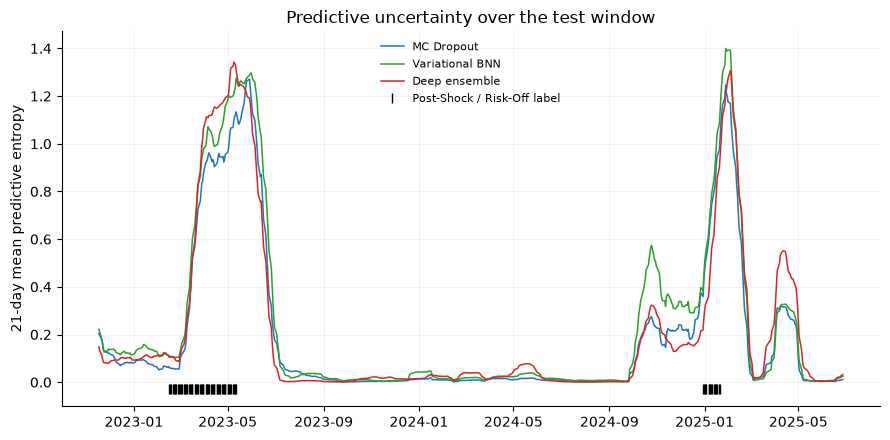

In [13]:
fig, ax = new_figure()
w = 21
for tag, name, c in [('mc', 'MC Dropout', PALETTE[0]), ('vi', 'Variational BNN', PALETTE[2]), ('ens', 'Deep ensemble', PALETTE[1])]:
    s = pd.Series(P[f'{tag}_total'], index=dates).rolling(w).mean()
    ax.plot(s.index, s.values, label=name, color=c)
stress_days = dates[np.isin(y, [3, 4])]
ax.plot(stress_days, np.full(len(stress_days), -0.03), '|', color='black', markersize=7, label='Post-Shock / Risk-Off label')
ax.set_ylabel(f'{w}-day mean predictive entropy')
ax.set_title('Predictive uncertainty over the test window')
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig('../docs/artifacts/day7_uncertainty_over_time.png', dpi=110)

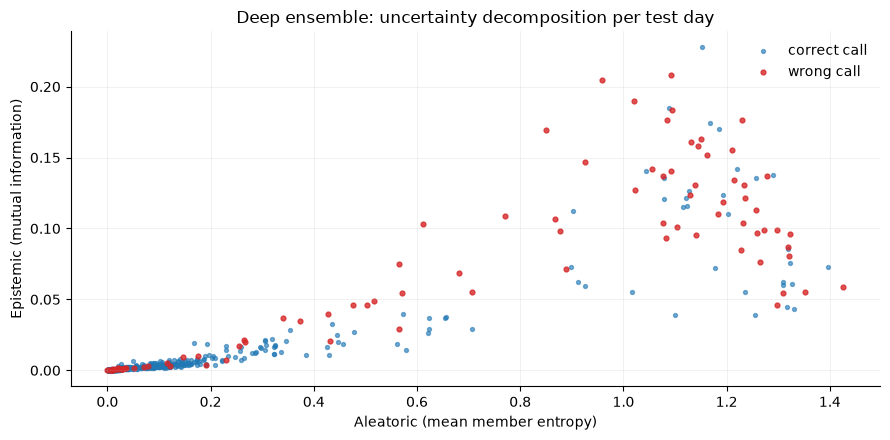

In [14]:
fig, ax = new_figure()
pred = P['ens_probs'].argmax(1); wrong = pred != y
ax.scatter(P['ens_aleatoric'][~wrong], P['ens_epistemic'][~wrong], s=8, color=PALETTE[0], label='correct call', alpha=0.6)
ax.scatter(P['ens_aleatoric'][wrong], P['ens_epistemic'][wrong], s=12, color=PALETTE[1], label='wrong call', alpha=0.8)
ax.set_xlabel('Aleatoric (mean member entropy)'); ax.set_ylabel('Epistemic (mutual information)')
ax.set_title('Deep ensemble: uncertainty decomposition per test day')
ax.legend()
fig.tight_layout(); fig.savefig('../docs/artifacts/day7_epistemic_vs_aleatoric.png', dpi=110)

In [15]:
rows = []
for c, r in enumerate(REGIMES):
    mk = y == c
    rows.append({'true label': r, 'days': int(mk.sum()),
                 'ensemble total': P['ens_total'][mk].mean(), 'ensemble aleatoric': P['ens_aleatoric'][mk].mean(),
                 'ensemble epistemic': P['ens_epistemic'][mk].mean(),
                 'VI total': P['vi_total'][mk].mean(), 'MC dropout total': P['mc_total'][mk].mean()})
pd.DataFrame(rows).set_index('true label')

,days,ensemble total,ensemble aleatoric,ensemble epistemic,VI total,MC dropout total
true label,,,,,,
Risk-On,601,0.108,0.103,0.006,0.130,0.096
Late-Cycle,7,0.266,0.250,0.015,0.625,0.531
Transitional,14,0.318,0.295,0.023,0.440,0.385
Post-Shock,41,0.976,0.881,0.095,0.996,0.854
Risk-Off,39,0.998,0.903,0.095,1.008,0.920


Uncertainty is far higher on Post-Shock and Risk-Off days (roughly
0.85-1.0 nats against about 0.1 on Risk-On), and the ensemble's *epistemic* part
rises most on exactly those days. Aleatoric still dominates
everywhere, which fits the Day 4-6 story: with returns-derived labels
and a heavily overlapping feature space, most of the ambiguity is not
something more training data would remove.

### Against the synthetic panel's true regimes

Only possible because this data is synthetic: the generator's actual
regime path is available and was never shown to any model. The HMM
labels the models trained on are a noisy version of it, so this is the
fairer test of whether the outputs track real stress. Two threshold-free
signals are compared as indicators of the true Risk-Off/Post-Shock
regimes: predictive entropy and the stress-class probability mass
`P(Post-Shock) + P(Risk-Off)`. Each is shown per day and as a trailing
21-day mean (past data only). Intervals are block bootstraps (21-day
blocks) because both the signals and the regimes are serially dependent.

In [16]:
from src.data.loader import DataConfig, load_market_data
truth = load_market_data(DataConfig(backend='synthetic', n_years=15.0, seed=7))['regime_path']['regime'].reindex(dates)
stress_true = truth.isin(['risk_off', 'post_shock']).values.astype(int)
print(f"True Risk-Off/Post-Shock days in the test window: {stress_true.sum()} of {len(y)}")

rng = np.random.default_rng(0)
def block_ci(sig, n_boot=200, block=21):
    n = len(sig); starts = np.arange(0, n - block + 1); out = []
    for _ in range(n_boot):
        idx = np.concatenate([np.arange(s0, s0 + block) for s0 in rng.choice(starts, size=int(np.ceil(n / block)))])[:n]
        if stress_true[idx].min() == stress_true[idx].max(): continue
        out.append(roc_auc_score(stress_true[idx], sig[idx]))
    return np.percentile(out, [2.5, 97.5])

rows = []
for tag, name in [('ens', 'Deep ensemble'), ('vi', 'Variational BNN'), ('mc', 'MC Dropout')]:
    probs = P[f'{tag}_probs']; tot = P[f'{tag}_total']; pstress = probs[:, 3] + probs[:, 4]
    sigs = {'entropy, per day': tot,
            'entropy, trailing 21d mean': pd.Series(tot).rolling(21, min_periods=1).mean().values,
            'P(Post-Shock)+P(Risk-Off), per day': pstress,
            'P(Post-Shock)+P(Risk-Off), trailing 21d mean': pd.Series(pstress).rolling(21, min_periods=1).mean().values}
    for k, v in sigs.items():
        lo, hi = block_ci(v)
        rows.append({'model': name, 'signal': k, 'AUROC vs true stress regime': f"{roc_auc_score(stress_true, v):.3f} [{lo:.3f}, {hi:.3f}]"})
pd.DataFrame(rows).set_index(['model', 'signal'])

True Risk-Off/Post-Shock days in the test window: 146 of 702


AUROC vs true stress regime
model           signal                                                                  
Deep ensemble   entropy, per day                                    0.876 [0.759, 0.976]
                entropy, trailing 21d mean                          0.911 [0.812, 0.985]
                P(Post-Shock)+P(Risk-Off), per day                  0.884 [0.788, 0.979]
                P(Post-Shock)+P(Risk-Off), trailing 21d mean        0.927 [0.852, 0.990]
Variational BNN entropy, per day                                    0.774 [0.568, 0.958]
                entropy, trailing 21d mean                          0.856 [0.698, 0.968]
                P(Post-Shock)+P(Risk-Off), per day                  0.816 [0.622, 0.972]
                P(Post-Shock)+P(Risk-Off), trailing 21d mean        0.912 [0.812, 0.986]
MC Dropout      entropy, per day                                    0.803 [0.642, 0.946]
                entropy, trailing 21d mean                          0.895 [0.759, 0.974]
                P(Post-Shock)+P(Risk-Off), per day                  0.829 [0.673, 0.964]
                P(Post-Shock)+P(Risk-Off), trailing 21d mean        0.922 [0.833, 0.985]

- Both signals track the true stress regimes to a useful degree: AUROCs
  run from about 0.77 to 0.93 across models and signals. **Treat this as
  evidence from two events, not 146 days**: the true stress regime in the
  test window is exactly two contiguous episodes (62 and 84 days), and a
  21-day block bootstrap cannot fully represent how little independent
  information that is. The intervals are wide for that reason, and are
  still likely optimistic.
- **Neither is shown to beat the other.** I expected predictive entropy to
  be the better stress indicator and checked; the stress-class
  probability mass scores as well or slightly better, with heavily
  overlapping intervals.
- Trailing 21-day means score higher than per-day values for every model
  and signal, consistent with regimes persisting.
- **This qualifies the recall results in Section 3.** The argmax label
  recovered only about 3-46% of Post-Shock/Risk-Off days, but the
  probabilities behind it rank days by stress much better than that. A
  rare class seldom wins the argmax against a ~89% base-rate class, yet
  its probability is systematically elevated on stress days. For rare
  regimes the argmax is the wrong operating point; the probabilities (or
  their trailing mean) are the more useful output.

In [17]:
s_ens = pd.Series(P['ens_total'], index=dates).rolling(21).mean()
high = (s_ens > 0.25).fillna(False).values          # 0.25 fixed before looking at the true regimes
stress_lab = np.isin(y, [3, 4])
near = np.zeros(len(dates), bool)
for d0 in dates[stress_lab]:
    near |= (dates >= d0 - pd.Timedelta(days=30)) & (dates <= d0 + pd.Timedelta(days=30))
unl = high & ~near
print(f"Ensemble: {high.sum()} high-uncertainty days (21d mean entropy > 0.25); {unl.sum()} lie more than 30 days from any HMM stress label.")
print("True generating regime on those", unl.sum(), "days:")
print(truth[unl].value_counts().to_string())

Ensemble: 153 high-uncertainty days (21d mean entropy > 0.25); 49 lie more than 30 days from any HMM stress label.
True generating regime on those 49 days:
regime
post_shock      19
risk_on         18
transitional    12


The figure above also shows uncertainty rising in stretches the HMM
labels as calm (mainly Oct-Nov 2024 and Apr 2025, plus the tails after
the two labelled episodes). Against the true regime path, most of those
days turn out to be true Post-Shock or Transitional rather than true
Risk-On, so they are mostly not false alarms, though some are (see the
count above).

## 5. SHAP attributions for selected dates

SHAP (KernelExplainer, 30-point k-means background) on the **deep
ensemble's mean predicted probability**, a deterministic function of the
inputs. MC Dropout and the variational BNN are stochastic per call, which
makes a point attribution ill-posed unless the random state is fixed.
Dates are chosen by stated rules (in `scripts/run_day7_shap.py`), not
hand-picked: most confident Risk-On; a correct Risk-Off; a *missed*
Risk-Off; the day of highest epistemic uncertainty; a correct Post-Shock.

In [18]:
S = np.load('../artifacts_data/day7_shap.npz', allow_pickle=True)
fn = list(S['feature_names'])
print(f"SHAP additivity check, max |base + sum(SHAP) - f(x)| over the five explanations: {S['additivity_error'].max():.2e}")
rows = []
for j, lab in enumerate(S['labels']):
    c = int(S['target_class'][j])
    rows.append({'case': lab, 'date': S['dates'][j], 'true': REGIMES[int(S['true_class'][j])],
                 'ensemble call': REGIMES[int(S['pred_class'][j])], 'explained output': f"P({REGIMES[c]})",
                 'base value': S['base_values'][c], 'f(x)': S['fx'][j, c], 'total entropy': S['total_entropy'][j]})
pd.DataFrame(rows).set_index('case')

SHAP additivity check, max |base + sum(SHAP) - f(x)| over the five explanations: 5.55e-17


,date,true,ensemble call,explained output,base value,f(x),total entropy
case,,,,,,,
A confident Risk-On,2024-07-29,Risk-On,Risk-On,P(Risk-On),0.861,1.000e+00,2.685e-04
B correct Risk-Off,2023-04-13,Risk-Off,Risk-Off,P(Risk-Off),0.040,4.054e-01,1.249e+00
C missed Risk-Off,2023-02-22,Risk-Off,Risk-On,P(Risk-Off),0.040,1.129e-04,1.142e-02
D highest epistemic,2025-01-13,Post-Shock,Post-Shock,P(Post-Shock),0.041,3.046e-01,1.379e+00
E correct Post-Shock,2023-05-08,Post-Shock,Post-Shock,P(Post-Shock),0.041,4.467e-01,1.290e+00


Top features by mean |SHAP| across the five dates:
usdinr_vol_21d         0.068
credit_spread          0.066
vol_21d                0.038
vol_21d_z              0.037
vol_63d                0.026
fii_eq_5d              0.011
gilt_10y_change_21d    0.010
spread_change_21d      0.009


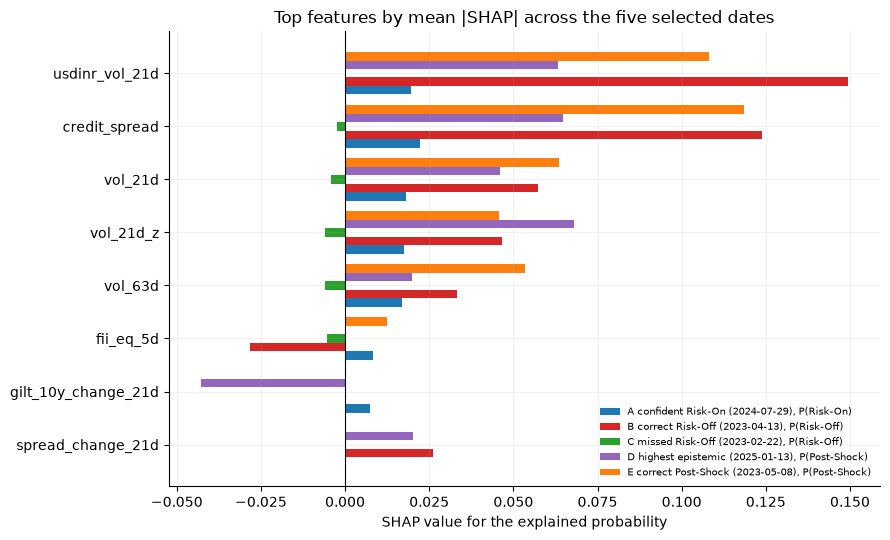

In [19]:
sv = S['shap_values']; tc = S['target_class']
per_date = np.stack([sv[j, :, int(tc[j])] for j in range(len(S['labels']))])   # (dates, features)
top = np.argsort(-np.abs(per_date).mean(0))[:8][::-1]

fig, ax = new_figure()
fig.set_size_inches(9, 5.5)
h = 0.16
for j, lab in enumerate(S['labels']):
    ypos = np.arange(len(top)) + (j - 2) * h
    ax.barh(ypos, per_date[j, top], height=h, color=PALETTE[j % 6],
            label=f"{lab} ({S['dates'][j]}), P({REGIMES[int(tc[j])]})")
ax.set_yticks(np.arange(len(top))); ax.set_yticklabels([fn[i] for i in top])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP value for the explained probability')
ax.set_title('Top features by mean |SHAP| across the five selected dates')
ax.legend(fontsize=7, loc='lower right')
fig.tight_layout(); fig.savefig('../docs/artifacts/day7_shap_selected_dates.png', dpi=110)
print("Top features by mean |SHAP| across the five dates:")
print(pd.Series(np.abs(per_date).mean(0), index=fn).sort_values(ascending=False).head(8).round(3).to_string())

**Reading the attributions.**

- **Which inputs drive the calls.** INR realised volatility, credit
  spread and equity volatility (`usdinr_vol_21d`, `credit_spread`,
  `vol_21d`, `vol_21d_z`, `vol_63d`) dominate, across the correct
  Risk-Off, correct Post-Shock and highest-epistemic-uncertainty days.
  This is what one would hope to see (stress shows up as volatility and
  spreads), but note *why* it happens here: in this **synthetic** panel
  those variables are regime-dependent by construction
  (`src/data/synthetic.py`). It shows the network found the regime-linked
  inputs; it is not evidence about which drivers matter in Indian markets.
- **Attribution is of the HMM label, not of reality.** SHAP explains
  what predicts the Day 4 pseudo-label.
- **The missed Risk-Off day is the instructive one.** P(Risk-Off) is
  essentially zero, every feature's attribution is tiny, and the
  ensemble's entropy is near zero: nothing in the inputs looked like
  stress, so the model was confidently wrong and no uncertainty measure
  could have warned about it. That matches the confident-miss counts in
  Section 4.
- **Confident Risk-On** has small attributions because Risk-On is the
  base rate: the prediction barely moves from the prior.
- SHAP values here are from 400 sampled coalitions with a 30-point
  background; they satisfy additivity exactly (check above) but are
  sampled estimates, and five dates are an illustration, not a global
  importance ranking.

## Summary

- MC Dropout, variational BNN and M=10 deep ensemble built per Sections
  A4.2-A4.4, compared on 5-fold time-series CV with the scaler fit inside
  each fold, reported against majority and class-prior baselines.
- Headline result, stated plainly: **none of the three reliably beats
  "always Risk-On"**, and none recovers Late-Cycle or Transitional. The
  labels they learn from inherit Day 4's 88.6% class imbalance and use
  future information.
- The variational BNN is the most consistent on NLL (below the prior in
  every fold); the three architectures are not separable given the
  fold-to-fold spread.
- The spec's ensemble recipe overfits here (worse than the class prior on
  NLL in 3 of 5 folds); the cause was traced to training length, and
  fixed with validation-based early stopping on the training window.
  Ensemble members are deterministic so their disagreement is genuinely
  epistemic.
- Uncertainty is informative on average (AUROC 0.84-0.86 for detecting
  wrong calls) but about one in five missed stress days is missed
  *confidently*; that limit is shown, not hidden. Against the synthetic
  true regime path, predictive entropy and the soft stress probability
  both track real stress (AUROC roughly 0.77-0.93) far better than the
  argmax recall suggests, and neither is shown to beat the other; but the
  test window contains only two true stress episodes, so this is thin
  evidence.
- SHAP attributions delivered for five rule-chosen dates, additivity
  verified, interpretation tied to how the synthetic data were built.

See `docs/day7_bdl_notes.md` for the full write-up.